# Goal

Given a training process, obtain the BFGS approximate Hessian (really, it's inverse), and see if it's a good approximation to the Gauss-Newton. 

In theory, the BFGS matrix is SPD and should be close to the Hessian, and the Gauss-Newton is a SPD truncation of the Hessian. Essentially, one's a rank two update of the other? 

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from functools import partial
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [2]:
# Create standard model
class MLP_1D(nn.Module):
    num_layers: int = 2
    hidden_dim: int = 6

    @nn.compact
    def __call__(self, x):
        # Input x is expected to be of shape (batch_size, 1)
        for _ in range(self.num_layers):
            residual = x
            x = nn.Dense(
                features=self.hidden_dim, use_bias=True,
                kernel_init=nn.initializers.kaiming_uniform(),  # Kaiming uniform initialization
                bias_init=nn.initializers.zeros  # Bias initialized to zero
            )(x)
            x = nn.tanh(x) + residual  # Apply activation function after each layer
        x = nn.Dense(features=1)(x)
        return x


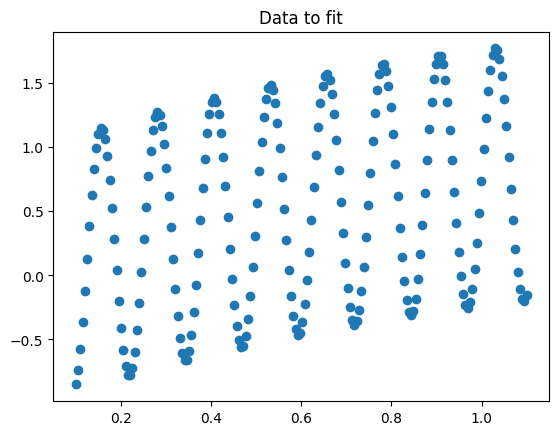

In [23]:
# Model definition 
L = 3
# n = 32
n = 4

num_samples = 200
# X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
X = jnp.linspace(0, 1, num_samples).reshape((-1, 1)) + .1
y = jnp.sin(16 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)
plt.title('Data to fit')
plt.show()
# zeros_to_append = jnp.zeros((num_samples, n-1))

# # Concatenate the original array and the zeros array along axis 1 (columns)
# X = jnp.concatenate((X, zeros_to_append), axis=1)
# y = jnp.concatenate((y, zeros_to_append), axis=1)
# treescope.display((X, y))



In [24]:
@jax.jit
def tree_dot(a, b):
    return jax.tree.reduce(
        lambda x, y: x + y,
        jax.tree.map(lambda x, y: jnp.vdot(x, y), a, b)
    )

@partial(jax.jit, static_argnames=['matvec', 'preconditioner', 'tol', 'max_iter'])
def conjugate_gradient(matvec, b, state, x, tol=1e-5, max_iter=1000, preconditioner=None):
    # If no preconditioner is provided, use the identity operation
    if preconditioner is None:
        preconditioner = lambda tree: tree
    
    def body_fn(carry):
        k, r, p, rsold, i = carry
        Ap = matvec(p)
        alpha = rsold / tree_dot(p, Ap)
        k = jax.tree.map(lambda k, p: k + alpha * p, k, p)
        r = jax.tree.map(lambda r, Ap: r - alpha * Ap, r, Ap)

        
        # Apply the preconditioner to the new residual
        z = preconditioner(r)
        rsnew = tree_dot(r, z) # Now it's r^T z instead of r^T r
        
        beta = rsnew / rsold
        p = jax.tree.map(lambda z_val, p_val: z_val + beta * p_val, z, p) # Update p using z
        return k, r, p, rsnew, i + 1

    def cond_fn(carry):
        _, _, _, rsnew, i = carry
        return jnp.logical_and(jnp.sqrt(rsnew) >= tol, i < max_iter)

    # k = jax.tree.map(jnp.zeros_like, b)  # Initial guess k = 0
    k = b
    r = jax.tree.map(lambda x: x, b)  # Initial residual r = b - A * k (A * k = 0 initially)
    p = jax.tree.map(lambda x: x, r)  # Initial direction p = r
    rsold = tree_dot(r, r)

    init_carry = (k, r, p, rsold, 0)
    k, r, p, rsnew, i = jax.lax.while_loop(cond_fn, body_fn, init_carry)

    return k, (jnp.sqrt(rsnew), i)


In [60]:
specific_epochs = [0, 5, 100]

def train_model_precond_cg(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=5e-2):
    print('Not intended for real training runs! Only to extract params ')
    
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Save grads 
        prior = grads 
        # print(grads['Dense_0']['bias'])
        # print(state.params['Dense_0']['bias'])
        # Conjugate gradient
        # TODO: figure out why 
        # _, f_jvp = jax.linearize(lambda p: 
                                 # state.apply_fn({'params': params}, batch_X), state.params)
        # worked so well? 
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, None, None, max_iter=1000,tol=1e-6
        )
        print(grads_cg['Dense_0']['bias'])

        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data, prior, grads_cg

    losses = []
    cg_stats = {
        'resids': [], 'iters': [],
        'params': [], 'rhs': [],
        'H_k': []
    }

    # Initialize BFGS stuff
    num_params = sum(param.size for param in jax.tree_util.tree_leaves(state.params)) 
    B_mat = jnp.eye(num_params)
    H_k = jnp.eye(num_params)
    df_k = None # Previous gradient 
    x_k = None # Previous weights
    
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        # if epoch > 0:
        #     # Update BFGS matrix
        #     s_k = 
        
        if epoch in specific_epochs:
            cg_stats['params'].append(
                state.params
            )
        state, loss, lm_data, prior, grads_cg = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

        # On first iteration
        if epoch == 0:
            df_k = jax.flatten_util.ravel_pytree(grads_cg)[0]
            x_k = jax.flatten_util.ravel_pytree(state.params)[0]
        else:
            # Construct the approximate Hessian 
            s_k = jax.flatten_util.ravel_pytree(state.params)[0] - x_k
            y_k = jax.flatten_util.ravel_pytree(grads_cg)[0] - df_k

            H_k = (jnp.eye(num_params) - jnp.outer(s_k, y_k) / (y_k.T @ s_k)) @ \
                    H_k @ (jnp.eye(num_params) - jnp.outer(y_k, s_k) / (y_k.T @ s_k)) + \
                    jnp.outer(s_k, s_k) / (y_k.T @ s_k)
            
            
        if epoch in specific_epochs:
            cg_stats['rhs'].append(
                prior
            )
            cg_stats['H_k'].append(H_k)
            
    return state, losses, cg_stats

num_epochs = 105
# num_epochs = 1

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_precond_cg, precond_losses_cg, cg_stats = train_model_precond_cg(
    X, y, model, params, learning_rate=2e-2, num_epochs=num_epochs, lamb=1e-2
)

Not intended for real training runs! Only to extract params 
Starting training for 105 epochs...


  0%|          | 0/105 [00:00<?, ?it/s]

Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace>


In [61]:
cg_stats['iters']

[<jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(22, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(23, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(22, dtype=int64, weak_type=True)>,
 <jax.Array(22, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(23, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(23, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(23, dtype=int64, weak_type=True)>,
 <jax.Array(20, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(22, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(22, dtype=int64, weak_type=True)>,
 <jax.Array(18, dtype=int64, weak_type=True)>,
 <jax.Array(19, dtype=int64, weak_type=True)>,
 <jax.Array(21, dtype=int64, weak_type=True)>,
 <jax

In [62]:
def make_matrix(params):
    jacobian = jax.jacobian(model.apply, argnums=0)({'params': params}, X)
    flattened, _ = jax.tree.flatten(jacobian)
    reshaped_leaves = [leaf.reshape(X.shape[0], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    jacobian = aggregated_array.reshape((X.shape[0], -1))
    jtj = jacobian.T @ jacobian
    
    lm_mat = 1e-2 * jnp.eye(jtj.shape[0]) + jtj
    return lm_mat 

def matrix_square_root_spd(A):
    eigenvalues, eigenvectors = jnp.linalg.eigh(A)
    eigenvalues = jnp.where(eigenvalues < 1e-12, 1e-12, eigenvalues)
    inverse_sqrt_eigenvalues = jnp.diag(jnp.sqrt(eigenvalues))
    A_inv_half = eigenvectors @ inverse_sqrt_eigenvalues @ eigenvectors.T
    return A_inv_half

In [63]:
index = 2
mat = make_matrix(cg_stats['params'][index]).astype('float32')
@jax.jit
def matvec(k):
    flat, back = jax.flatten_util.ravel_pytree(k)
    Av = mat @ flat
    return back(Av)

matrix_sol, lm_data = conjugate_gradient(
    matvec, cg_stats['rhs'][index], None, None, max_iter=1000,tol=1e-6
)
print(f'Using constructed matrix: \t{lm_data[1]} iterations')

_, f_jvp = jax.linearize(lambda p: 
                         model.apply({'params': p}, X), 
                         cg_stats['params'][index])
f_vjp = jax.linear_transpose(f_jvp, cg_stats['params'][index])
@jax.jit
def matvec(k):
    Av = f_vjp(f_jvp(k))[0]
    # Add the regularization term lambda * k
    Av = jax.tree_util.tree_map(lambda a, b: a + 1e-2 * b, Av, k)
    return Av


matvec_sol, lm_data = conjugate_gradient(
    matvec, cg_stats['rhs'][index], None, None, max_iter=1000,tol=1e-6
)
print(f'Using matrix free:\t\t {lm_data[1]} iterations')

Using constructed matrix: 	34 iterations
Using matrix free:		 19 iterations


In [68]:
jnp.linalg.inv(mat)

<jax.Array float32(53, 53) ≈1.8 ±1.3e+01 [≥-2.8e+01, ≤1e+02] nonzero:2_809
  <Arrayviz rendering>
| Device: GPU 0>

In [69]:
cg_stats['H_k'][index]

<jax.Array float64(53, 53) ≈0.019 ±0.13 [≥-0.19, ≤1.0] nonzero:2_809
  <Arrayviz rendering>
| Device: GPU 0>

In [77]:
precond = matrix_square_root_spd(
    # (cg_stats['H_k'][index])
    cg_stats['H_k'][index]
)

In [75]:
eigs = jnp.linalg.eigvalsh(precond @ mat @ precond.T)
print(f'{jnp.max(eigs) / jnp.min(eigs):.2e}')

2.10e+07


In [76]:
eigs = jnp.linalg.eigvalsh( mat )
print(f'{jnp.max(eigs) / jnp.min(eigs):.2e}')

3.35e+05
